# Used Car Price Prediction Model

In [1]:
# import modules 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [2]:
# import dataset
df = pd.read_csv(r'C:\Users\Dell\Downloads\archive (15)\Used Car Dataset.csv', encoding = 'latin-1')
df

,Unnamed: 0,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548,1548,2020 Hyundai Creta SX Opt Diesel AT BSVI,Aug-20,Comprehensive,Diesel,5,35000,First Owner,Automatic,2020,1493.00,11345.0,11345.0,250.0,17.41
1549,1549,2022 Renault KWID 1.0 RXL Opt BSVI,2022,Third Party insurance,Petrol,5,10000,999 cc,2022,Power Steering,999.00,6706.0,6706.0,91.0,3.98
1550,1550,2017 Honda WR-V i-VTEC S,Jun-17,Comprehensive,Petrol,5,49000,First Owner,Manual,2017,17.50,1199.0,1199.0,887.0,5.85
1551,1551,2018 Volkswagen Polo 1.0 MPI Comfortline,May-18,Comprehensive,Petrol,5,40000,Second Owner,Manual,2018,18.78,999.0,999.0,75.0,4.75


In [3]:
df.columns

Index(['Unnamed: 0', 'car_name', 'registration_year', 'insurance_validity',
       'fuel_type', 'seats', 'kms_driven', 'ownsership', 'transmission',
       'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)', 'price(in lakhs)'],
      dtype='str')

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1553 entries, 0 to 1552
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1553 non-null   int64  
 1   car_name            1553 non-null   str    
 2   registration_year   1553 non-null   str    
 3   insurance_validity  1553 non-null   str    
 4   fuel_type           1553 non-null   str    
 5   seats               1553 non-null   int64  
 6   kms_driven          1553 non-null   int64  
 7   ownsership          1553 non-null   str    
 8   transmission        1553 non-null   str    
 9   manufacturing_year  1553 non-null   str    
 10  mileage(kmpl)       1550 non-null   float64
 11  engine(cc)          1550 non-null   float64
 12  max_power(bhp)      1550 non-null   float64
 13  torque(Nm)          1549 non-null   float64
 14  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(3), str(7)
memory usage: 182.1 KB


In [5]:
df.describe().round()

,Unnamed: 0,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,1553.0,1553.0,1553.0,1550.0,1.550000e+03,1.550000e+03,1549.0,1553.0
mean,776.0,91.0,52842.0,237.0,1.471857e+10,1.471857e+10,14240.0,166.0
std,448.0,2403.0,40068.0,586.0,2.185629e+11,2.185629e+11,96662.0,3479.0
min,0.0,4.0,620.0,8.0,5.000000e+00,5.000000e+00,5.0,1.0
25%,388.0,5.0,30000.0,16.0,1.197000e+03,1.197000e+03,400.0,5.0
50%,776.0,5.0,49134.0,19.0,1.462000e+03,1.462000e+03,1173.0,7.0
75%,1164.0,5.0,70000.0,22.0,1.995000e+03,1.995000e+03,8850.0,17.0
max,1552.0,67000.0,810000.0,3996.0,3.258640e+12,3.258640e+12,1464800.0,95000.0


In [6]:
df.iloc[1277].reset_index() # checking irrelavant rows , since 95000 lakhs valuation is not acceptable for this car model. So, it must be a outlier

,index,1277
0,Unnamed: 0,1277
1,car_name,2009 Maruti Alto 800 LXi
2,registration_year,May-09
3,insurance_validity,Comprehensive
4,fuel_type,Petrol
5,seats,5
6,kms_driven,44002
7,ownsership,Third Owner
8,transmission,Manual
9,manufacturing_year,2009


In [7]:
df.isnull().sum()

Unnamed: 0            0
car_name              0
registration_year     0
insurance_validity    0
fuel_type             0
seats                 0
kms_driven            0
ownsership            0
transmission          0
manufacturing_year    0
mileage(kmpl)         3
engine(cc)            3
max_power(bhp)        3
torque(Nm)            4
price(in lakhs)       0
dtype: int64

In [8]:
# Removing irrelavant rows and columns

df.drop(columns = 'Unnamed: 0', inplace = True)
df.drop(df[df.duplicated()].index, inplace = True)
df.drop(columns = ['engine(cc)'], inplace = True)
df.drop(1128,inplace = True)
df = df.rename(columns = {'ownsership' : 'ownership'})


## Data Cleaning

In [9]:
# Step 1: handling missing values

df['mileage(kmpl)'] =  df['mileage(kmpl)'].fillna(df['mileage(kmpl)'].median())
df['max_power(bhp)'] = df['max_power(bhp)'].fillna(df['max_power(bhp)'].median())
df['torque(Nm)'] = df['torque(Nm)'].fillna(df['torque(Nm)'].median())

# We filled with median because almost every feature have outliers

In [10]:
# Step 2:  Fixing inconsistent formatting
for col in df.columns: 
    if df[col].nunique() < 20:
        print('Col_name: ')
        print(df[col].value_counts())
        print('-' * 50)

Col_name: 
insurance_validity
Comprehensive            789
Third Party insurance    233
Third Party               56
Zero Dep                  52
Petrol                     1
Not Available              1
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
fuel_type
Petrol     751
Diesel     363
CNG         17
5 Seats      1
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
seats
5        995
7        108
4         15
6         11
8          2
67000      1
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
transmission
Manual                 645
Automatic              462
2017                     8
2014                     3
2023                     2
2021                     2
2011                     2
2022                     2
2018                     2
2020                     1
Power Windows Front      1
2015                     1
2016                     1
Name: count, d

In [11]:
df['insurance_validity'] = df['insurance_validity'].replace({'Third Party' : 'Third Party insurance'})
df['fuel_type'] = df['fuel_type'].replace({'5 Seats' : 'Petrol'})

### Extracitng registration year and formatting
import re
def extract_year(registration_year):
    year_num = re.findall(r'[0-9]+',(registration_year))
    return [int(x) for x in year_num]
df['registration_year'] = df['registration_year'].apply(lambda x: extract_year(x)).astype(str)
df['registration_year'] = df['registration_year'].fillna(df['registration_year'].mode()[0])
df['registration_year'] = df['registration_year'].apply(lambda x: x.strip('[]'))

def year_formatter(year):
    if len(year) == 1:
        return '200' + year
    elif len(year) == 2:
        return '20' + year
    else:
        return year
df['registration_year'] = df['registration_year'].apply(year_formatter)

### Extracting car name
def car_name(name):
    real_name = re.sub(r'[0-9]+','',name)
    return real_name
df['car_name'] = df['car_name'].apply(car_name)



for col in df.columns:          # prints the value_counts of the columns which have unique values less than 20
    if df[col].nunique() < 20:
        print('Col_name: ')
        print(df[col].value_counts())
        print('-' * 50)
df['registration_year'].unique()


Col_name: 
registration_year
2018    171
2017    141
2019    133
2016    103
2015     98
2020     96
2021     86
2014     79
2022     75
2013     37
2012     36
2023     30
2011     22
2010     14
2009      9
          1
2007      1
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
insurance_validity
Comprehensive            789
Third Party insurance    289
Zero Dep                  52
Petrol                     1
Not Available              1
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
fuel_type
Petrol    752
Diesel    363
CNG        17
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
seats
5        995
7        108
4         15
6         11
8          2
67000      1
Name: count, dtype: int64
--------------------------------------------------
Col_name: 
transmission
Manual                 645
Automatic              462
2017                     8
2014                 

<StringArray>
['2017', '2021', '2018', '2019', '2015', '2020', '2022', '2014', '2010',
 '2011', '2023', '2016', '2009', '2013', '2012',     '', '2007']
Length: 17, dtype: str

In [12]:
# Arranging the data in the correct column

transmission_type = ['Automatic','Manual','Power Windows Front']
a = df.loc[~df.transmission.isin(transmission_type),'manufacturing_year']
b = df.loc[~df.transmission.isin(transmission_type),'transmission']
temp = a
a = b
b = temp
df.loc[~df.transmission.isin(transmission_type),'manufacturing_year'] = a
df.loc[~df.transmission.isin(transmission_type),'transmission']  = b
df.drop(df.loc[df.manufacturing_year == 'Air Conditioner'].index, inplace = True)
df = df.reset_index()


In [13]:
type_ownership  = ['First Owner', 'Second Owner' ,'Third Owner','Fifth Owner']
df.loc[~df.ownership.isin(type_ownership), 'ownership'] = df['ownership'].mode()[0]
df['ownership']   = df['ownership'].fillna(df['ownership'].mode()[0])


In [14]:
# Step 3: Handling Duplicates
# There are not duplicate entries, we have sorted that problem in upper blocks of code


In [15]:
# Step 4: Correcting Datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1131 entries, 0 to 1130
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1131 non-null   int64  
 1   car_name            1131 non-null   str    
 2   registration_year   1131 non-null   str    
 3   insurance_validity  1131 non-null   str    
 4   fuel_type           1131 non-null   str    
 5   seats               1131 non-null   int64  
 6   kms_driven          1131 non-null   int64  
 7   ownership           1131 non-null   str    
 8   transmission        1131 non-null   str    
 9   manufacturing_year  1131 non-null   str    
 10  mileage(kmpl)       1131 non-null   float64
 11  max_power(bhp)      1131 non-null   float64
 12  torque(Nm)          1131 non-null   float64
 13  price(in lakhs)     1131 non-null   float64
dtypes: float64(4), int64(3), str(7)
memory usage: 123.8 KB


In [16]:
df['registration_year'] = pd.to_datetime(df['registration_year'],format = '%Y')
df['manufacturing_year'] = pd.to_datetime(df['manufacturing_year'],format = '%Y')


In [17]:
df.info() # Cheking Datatypes

<class 'pandas.DataFrame'>
RangeIndex: 1131 entries, 0 to 1130
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   index               1131 non-null   int64         
 1   car_name            1131 non-null   str           
 2   registration_year   1131 non-null   datetime64[us]
 3   insurance_validity  1131 non-null   str           
 4   fuel_type           1131 non-null   str           
 5   seats               1131 non-null   int64         
 6   kms_driven          1131 non-null   int64         
 7   ownership           1131 non-null   str           
 8   transmission        1131 non-null   str           
 9   manufacturing_year  1131 non-null   datetime64[us]
 10  mileage(kmpl)       1131 non-null   float64       
 11  max_power(bhp)      1131 non-null   float64       
 12  torque(Nm)          1131 non-null   float64       
 13  price(in lakhs)     1131 non-null   float64       
dtypes: 

In [18]:
# Step 5 : Handling Outliers by IQR method

df.describe().round()

,index,registration_year,seats,kms_driven,manufacturing_year,mileage(kmpl),max_power(bhp),torque(Nm),price(in lakhs)
count,1131.0,1131,1131.0,1131.0,1131,1131.0,1.131000e+03,1131.0,1131.0
mean,861.0,2017-05-25 07:44:43.289124,5.0,53118.0,2017-04-28 20:17:11.299734,221.0,1.152627e+10,14412.0,160.0
min,0.0,2007-01-01 00:00:00,4.0,620.0,2007-01-01 00:00:00,8.0,5.000000e+00,17.0,1.0
25%,464.0,2015-01-01 00:00:00,5.0,30000.0,2015-01-01 00:00:00,17.0,1.197000e+03,432.0,4.0
50%,953.0,2018-01-01 00:00:00,5.0,49000.0,2018-01-01 00:00:00,19.0,1.461000e+03,1176.0,7.0
75%,1260.0,2020-01-01 00:00:00,5.0,70000.0,2019-01-01 00:00:00,22.0,1.991000e+03,8850.0,15.0
max,1552.0,2023-01-01 00:00:00,8.0,810000.0,2023-01-01 00:00:00,3996.0,3.258640e+12,1464800.0,95000.0
std,459.0,NaN,1.0,43079.0,NaN,557.0,1.935342e+11,95471.0,3507.0


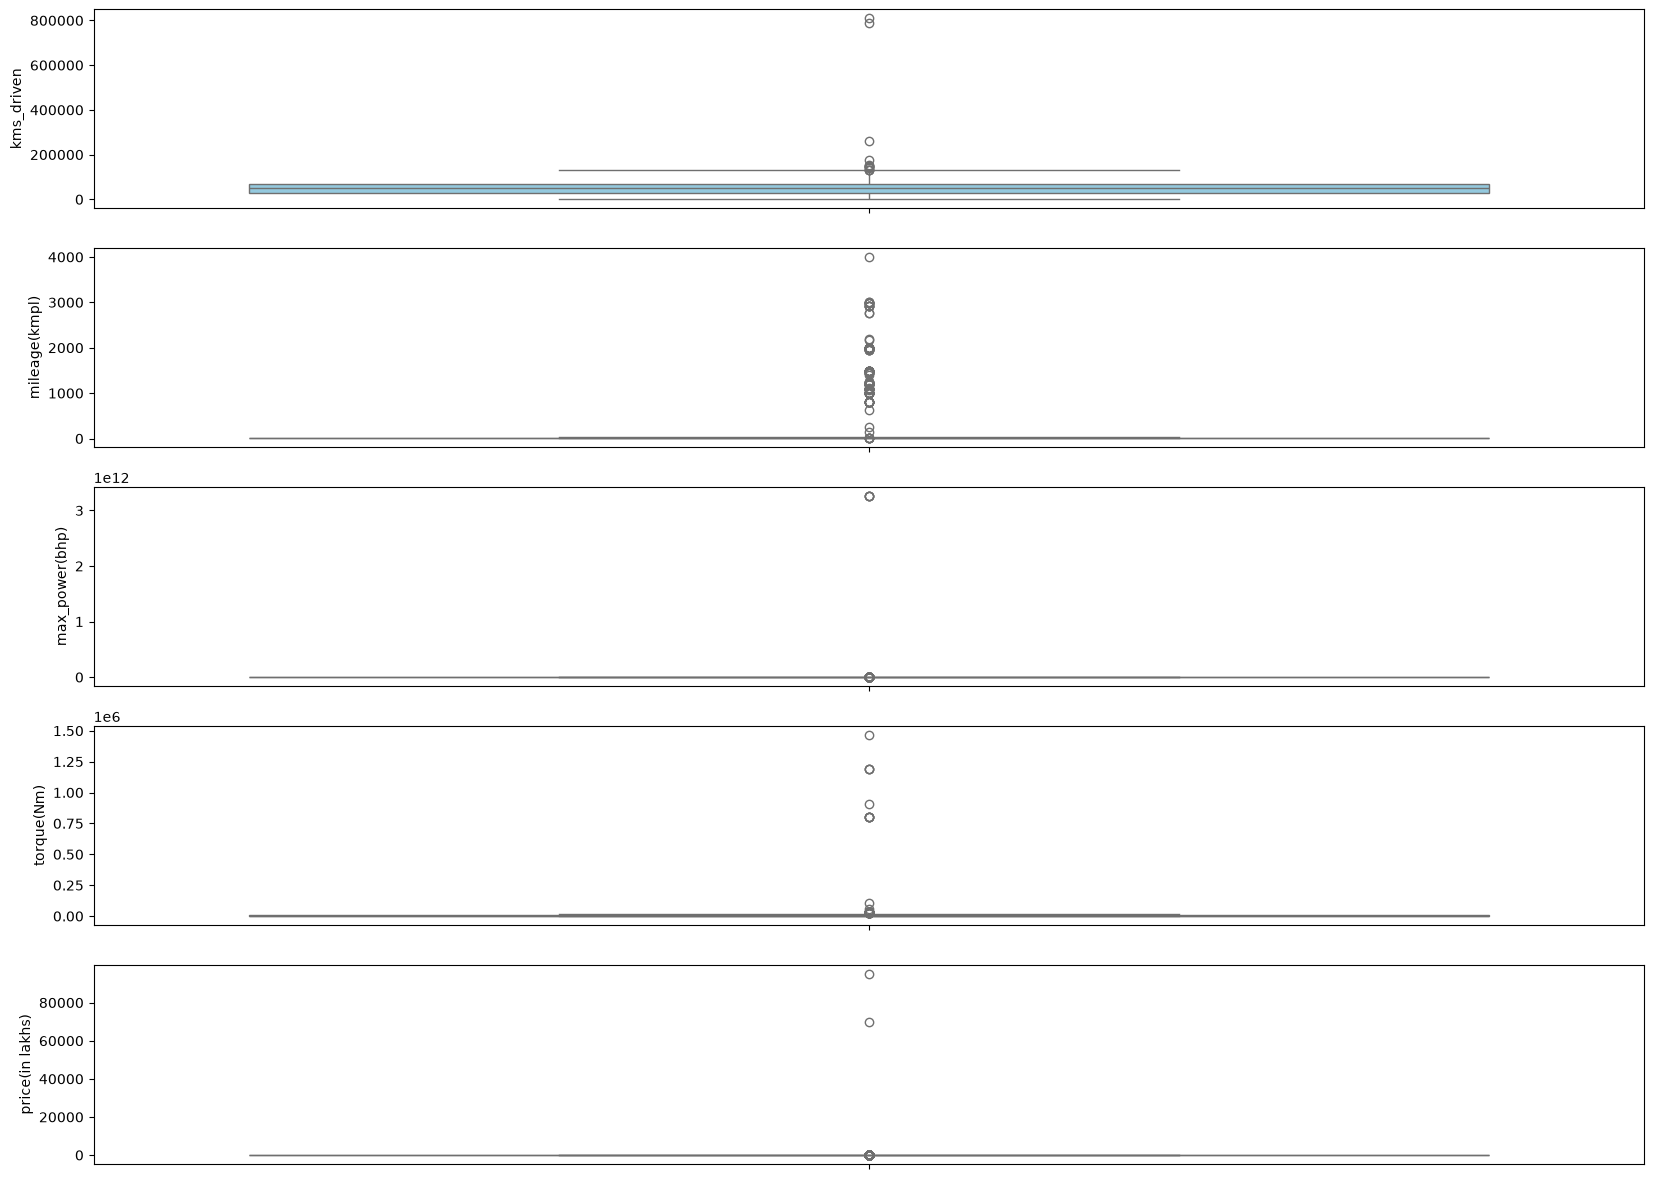

In [19]:
# plotting outliers in boxplots

cols = ['kms_driven','mileage(kmpl)','max_power(bhp)','torque(Nm)','price(in lakhs)']
plt.figure(figsize= (20,15))
for i , col in enumerate(cols,1):
    plt.subplot(5,1,i)
    sns.boxplot(df[col],color = 'skyblue')
plt.show()
    

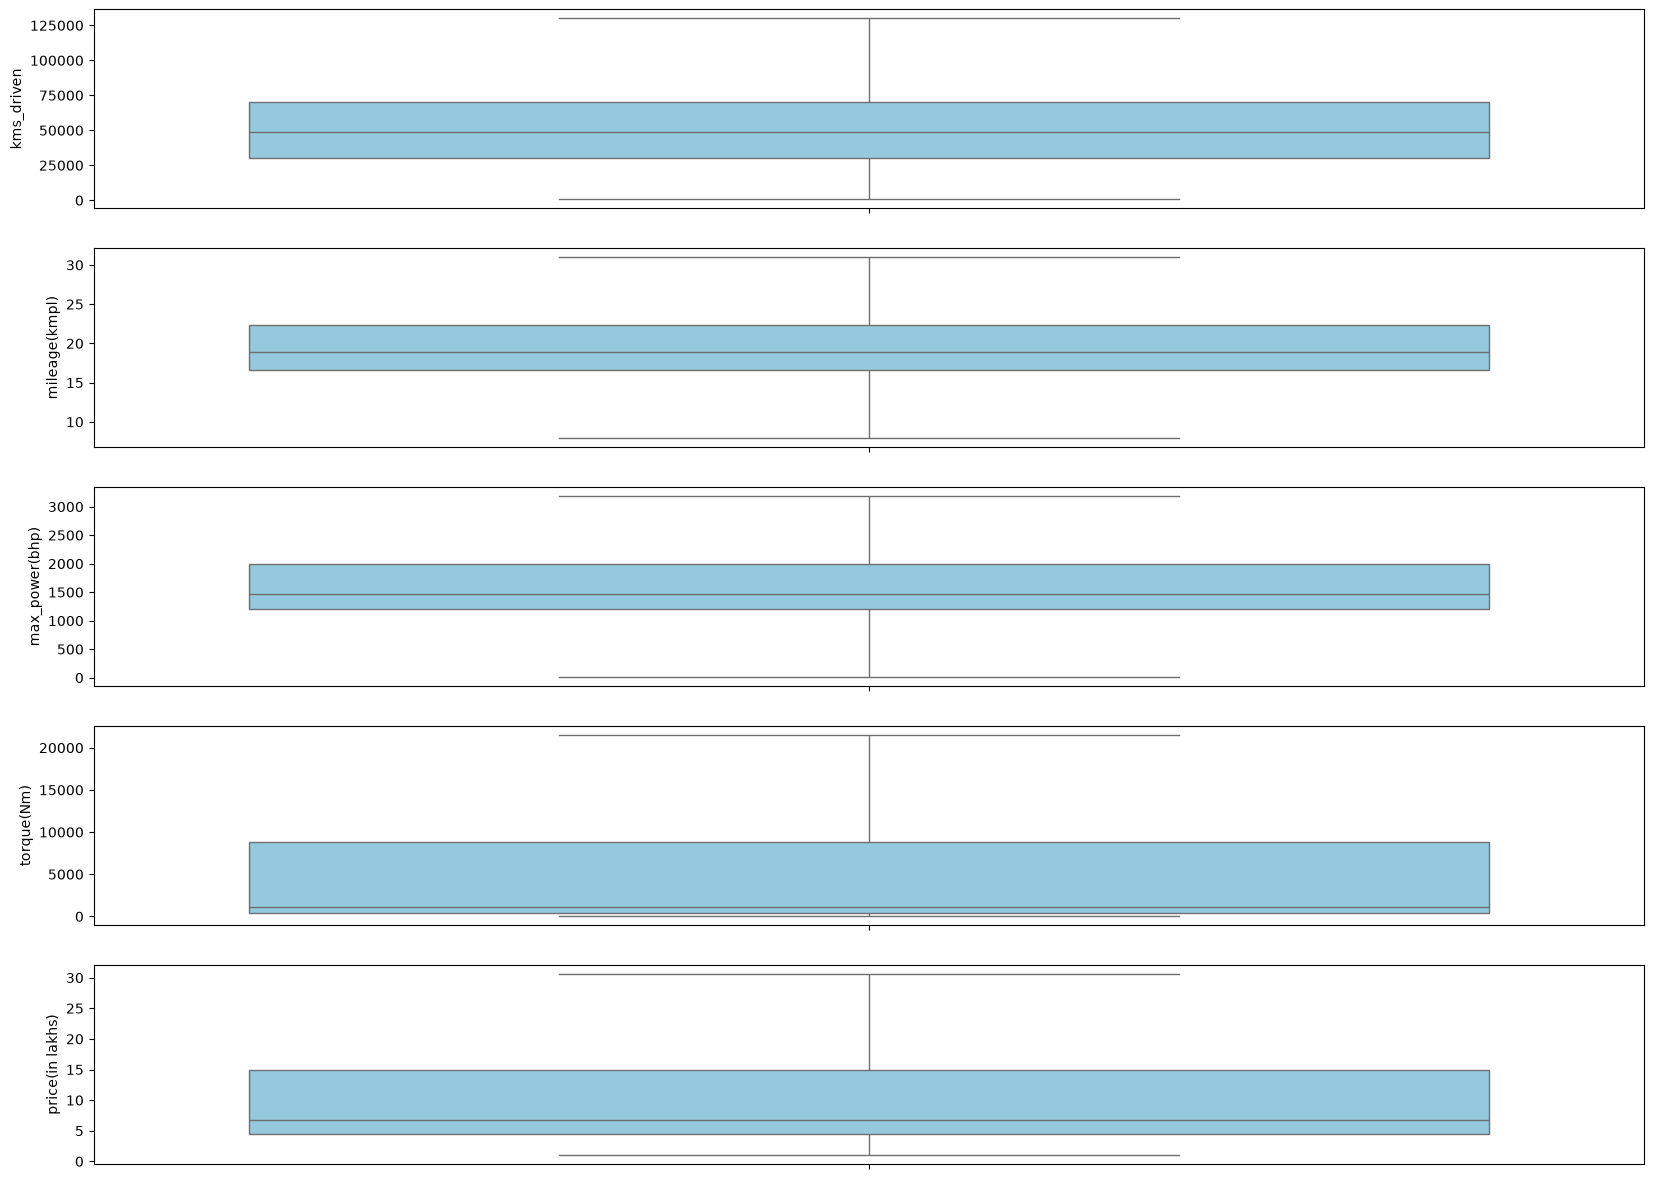

In [20]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    df[col] = df[col].clip(lower_limit, upper_limit)

# Checking Outliers
plt.figure(figsize= (20,15))
for i , col in enumerate(cols,1):
    plt.subplot(5,1,i)
    sns.boxplot(df[col],color = 'skyblue')
plt.show()

# Here, there are no outlier present in the boxplots


    

In [21]:
#Step 6: Saving Dataset
df.to_csv('used_car_price_prediction_model_cleaned.csv',index = False)

## Feature Engineering


In [22]:
df.drop(columns = 'index',inplace = True)
df['registration_year'] = df['registration_year'].dt.year
df['manufacturing_year'] = df['manufacturing_year'].dt.year

In [23]:
df['n_of_years_old'] = ((pd.Timestamp.today().year - df['manufacturing_year']))
df.drop(columns = ['registration_year','manufacturing_year'],inplace = True)
df

,car_name,insurance_validity,fuel_type,seats,kms_driven,ownership,transmission,mileage(kmpl),max_power(bhp),torque(Nm),price(in lakhs),n_of_years_old
0,Mercedes-Benz S-Class S,Comprehensive,Petrol,5,56000,First Owner,Automatic,7.895,2996.0,333.0,30.5625,9
1,Nissan Magnite Turbo CVT XV Premium Opt BSVI,Comprehensive,Petrol,5,30615,First Owner,Automatic,17.400,999.0,9863.0,8.9900,6
2,BMW X sDrive d xLine,Comprehensive,Diesel,5,24000,First Owner,Automatic,20.680,1995.0,188.0,23.7500,8
3,Kia Seltos GTX Plus,Comprehensive,Petrol,5,18378,First Owner,Manual,16.500,1353.0,13808.0,13.5600,7
4,Skoda Superb LK . TSI AT,Comprehensive,Petrol,5,44900,First Owner,Automatic,14.670,1798.0,17746.0,24.0000,7
...,...,...,...,...,...,...,...,...,...,...,...,...
1126,Hyundai Creta SX Opt Diesel AT BSVI,Comprehensive,Diesel,5,35000,First Owner,Automatic,30.975,3182.0,250.0,17.4100,6
1127,Renault KWID . RXL Opt BSVI,Third Party insurance,Petrol,5,10000,First Owner,Power Steering,30.975,3182.0,91.0,3.9800,4
1128,Honda WR-V i-VTEC S,Comprehensive,Petrol,5,49000,First Owner,Manual,17.500,1199.0,887.0,5.8500,9
1129,Volkswagen Polo . MPI Comfortline,Comprehensive,Petrol,5,40000,Second Owner,Manual,18.780,999.0,75.0,4.7500,8


## Label Encoding

In [24]:
# car name: target encoding on the basis of max_power
target_enc = df.groupby('car_name')['price(in lakhs)'].mean().to_dict()
df['car_name'] = df['car_name'].map(target_enc)

# insuranace_validity: one hot encoding
df = pd.get_dummies(data= df, columns= ['insurance_validity','fuel_type'], prefix = ['insurance','fuel'])
cols = ['insurance','fuel']
dict = {True: 1 , False: 0}
for col in df.columns:
    for word in cols:
        if word in col:
            df[col] = df[col].map(dict)



In [25]:
# ownership: OrdinalEncoding
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories= [['First Owner', 'Second Owner', 'Third Owner', 'Fifth Owner']])
df['ownership'] = encoder.fit_transform(df[['ownership']])

In [26]:
# transmission: Label encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['transmission'] = encoder.fit_transform(df['transmission'])

In [27]:
df['transmission'].unique()

array([0, 1, 2, 3])

In [28]:
target = df.pop('price(in lakhs)')
df['price(in lakhs)'] = target


## Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns = 'price(in lakhs)')
y = df['price(in lakhs)']
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 32)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [30]:
le = LinearRegression()
le.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ 8.84, 0.01,-0.2 ,...,-0. , 0.03,-0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.67
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[52.67,45.52,40.53,...,18.03, 0. , 0. ]"


In [31]:
print('Train_score: ',le.score(X_train_scaled,y_train))
print('Test Score:',le.score(X_test_scaled, y_test))

Train_score:  0.9569357491962356
Test Score: 0.9703079767132649


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = le.predict(X_test_scaled)

print("R²   :", le.score(X_test_scaled, y_test))
print("MAE  :", mean_absolute_error(y_test, y_pred))
print("MSE  :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R²   : 0.9703079767132649
MAE  : 0.7387403563010131
MSE  : 3.009508166675361
RMSE : 1.7347934074913245


In [33]:
print(df.shape)
print(df.isnull().sum().sum())

(1131, 17)
0


In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    le,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)
print("Mean R²:", scores.mean())

[0.94817363 0.94465439 0.9842107  0.92073162 0.97103882]
Mean R²: 0.9537618338389715
